In [ ]:
!pip install langchain-google-genai rouge-score bert-score json-repair

In [ ]:
from google.colab import userdata
import json_repair
from datasets import load_dataset, DatasetDict, Dataset
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.model_selection import train_test_split
from rouge_score import rouge_scorer
from bert_score import score as bert_score
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from google.colab import drive
import os
import re
drive.mount('/content/drive')
device = "cuda"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def parse_json(text):
    try:
        return json_repair.loads(text)
    except:
        return None

## **Load Data**

In [ ]:
!hf auth login

In [ ]:
df = load_dataset("memray/FacetSum")
df

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'keywords', 'url', 'section_names', 'sections', 'abstract_sections_names', 'abstract_sections', 'references', 'appendix', 'journal', 'id', 'category'],
        num_rows: 187046
    })
    validation: Dataset({
        features: ['title', 'keywords', 'url', 'section_names', 'sections', 'abstract_sections_names', 'abstract_sections', 'references', 'appendix', 'journal', 'id', 'category'],
        num_rows: 12000
    })
    test: Dataset({
        features: ['title', 'keywords', 'url', 'section_names', 'sections', 'abstract_sections_names', 'abstract_sections', 'references', 'appendix', 'journal', 'id', 'category'],
        num_rows: 8243
    })
})

In [ ]:
train_df = df['train'].to_pandas()
val_df = df['validation'].to_pandas()
test_df = df['test'].to_pandas()

In [ ]:
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

In [ ]:
df.duplicated(subset=["title", "url"]).sum()

np.int64(100506)

In [ ]:
df = df.drop_duplicates(subset=["title", "url"])

In [ ]:
df.shape

(106783, 12)

In [ ]:
df.head(1)

,title,keywords,url,section_names,sections,abstract_sections_names,abstract_sections,references,appendix,journal,id,category
0,Unpacking the combined effects of job scope an...,"[Supervisor support, In-role performance, Job ...",https://www.emerald.com/insight/content/doi/10...,"[Introduction, Theoretical background and hypo...",[[Organizations of various sectors are not giv...,"[Purpose, Design/methodology/approach, Finding...",[[The purpose of this paper is to explore how ...,"[Ali, N. and Zia-ur-Rehman, M. (2014), ""Impact...",,Journal of Management Development,6iPYReXvkVNFkzQ9CzLLAG,Human Resource Management


In [ ]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = text.strip()
    return text


def keep_only_clean_papers(data):

    target_sections = ["Purpose", "Design/methodology/approach", "Findings", "Originality/value"]

    refs = data.get("references")
    refs_ok = refs is not None and len(refs) > 0

    sections_ok = list(data.get("abstract_sections_names")) == target_sections

    section_names = data.get("section_names", [])
    section_len_ok = len(section_names) >= 3

    normalized_sections = [normalize_text(s) for s in section_names]

    has_intro = any("intro" in s for s in normalized_sections)
    has_conclusion = any("concl" in s for s in normalized_sections)

    return refs_ok and sections_ok and section_len_ok and has_intro and has_conclusion

In [ ]:
df = df[df.apply(keep_only_clean_papers, axis=1)]
df.head(1)

,title,keywords,url,section_names,sections,abstract_sections_names,abstract_sections,references,appendix,journal,id,category
1,"Family firms, board structure and firm perform...","[India, Family firms, Corporate governance, Fi...",https://www.emerald.com/insight/content/doi/10...,"[1. Introduction, 2. Potential benefits of fam...",[[Family businesses are the most dominant amon...,"[Purpose, Design/methodology/approach, Finding...",[[Given the prevalence of family-run businesse...,"[Agrawal, A. and Knoeber, C.R. (1996), ""Firm p...",,International Journal of Law and Management,ffXyLGv9ncNzR8HRExq8zx,Business Ethics and Law


In [ ]:
df.shape

(30678, 12)

In [ ]:
def get_word_counts(doc):
    word_counts = []
    total_words = 0
    for section in list(doc):
      for text in list(section):
        words = str(text).split()
        total_words += len(words)

    word_counts.append(total_words)

    return word_counts

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df['sections'][0]

array([array(['Family businesses are the most dominant among publically traded firms across the world (Shleifer and Vishny, 1986; Burkart et al., 2003; Anderson and Reeb, 2003; La Porta et al., 1999). In Continental Europe, about 44 per cent of publicly held firms are family-controlled (Faccio and Lang, 2002). In the USA, the equity ownership concentration is modest; among the Fortune 500 firms, around one-third is family firms (Anderson and Reeb, 2003). The concentration of ownership was found to be higher in other developed nations (Faccio and Lang, 2002; Franks and Mayer, 2001; Gorton and Schmid, 1996). Family businesses dominate many developing economies with about two-third of the firms in Asian countries owned by families or individuals (Claessens et al., 2000). In India, around 60 per cent of the listed top 500 firms are family firms (Chakrabarti et al., 2008). These family firms hold large equity stakes and more often than not have family representation on the board of director

In [ ]:
df['paper_word_count'] = df['sections'].apply(get_word_counts)

In [ ]:
def visual_data(counts, color, title):
  plt.figure(figsize=(8,5))
  plt.hist(counts, bins=30, color=color)
  plt.title(f"{title} Word Count Distribution")
  plt.xlabel("Number of Words per Paper")
  plt.ylabel("Frequency")
  plt.show()

In [ ]:
print(min(df['paper_word_count']))
print(max(df['paper_word_count']))

[423]
[41717]


In [ ]:
df['paper_word_count'] = df['paper_word_count'].apply(lambda x: x[0] if isinstance(x, list) else x)
df['paper_word_count'] = df['paper_word_count'].astype(int)

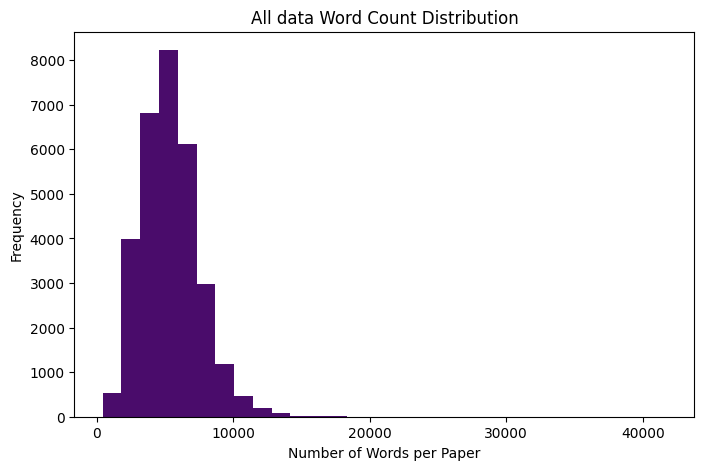

In [ ]:
visual_data(df['paper_word_count'], color="#4a0c6b", title="All data")

In [ ]:
lower_limit = df['paper_word_count'].quantile(0.05)
upper_limit = df['paper_word_count'].quantile(0.95)

df = df[(df['paper_word_count'] > lower_limit) & (df['paper_word_count'] < upper_limit)]

print(f"Minimum number of paper words: {df['paper_word_count'].min()}")
print(f"Maximum number of paper words: {df['paper_word_count'].max()}")

Minimum number of paper words: 2339
Maximum number of paper words: 9068


In [ ]:
df.shape

(27609, 13)

In [ ]:
df['category'].unique()

array(['Business Ethics and Law', 'Learning and Development',
       'Industry and Public Sector Management', 'Economics',
       'Managing Quality', 'Organization Studies',
       'Health Care Management / Healthcare',
       'Information and Knowledge Management', 'Education',
       'Environmental Management / Environment',
       'Library and Information Science',
       'Management Science / Management Studies',
       'Health and Social Care', 'Accounting and Finance', 'Marketing',
       'Human Resource Management', 'Strategy', 'Built Environment',
       'Operations and Logistics Management', 'Tourism and Hospitality',
       'Performance Management and Measurement',
       'Enterprise and Innovation',
       'Mechanical and Materials Engineering', 'International Business',
       'Regional Management Studies',
       'Electrical and Electronic Engineering',
       'Sociology and Public Policy'], dtype=object)

In [ ]:
df['category'].value_counts()


,count
category,
Mechanical and Materials Engineering,4520
Economics,2024
Built Environment,1970
Information and Knowledge Management,1962
Accounting and Finance,1641
Industry and Public Sector Management,1572
Education,1450
Marketing,1427
Electrical and Electronic Engineering,1140


In [ ]:
df = df[df['category'].map(df['category'].value_counts()) > 100]
df.reset_index(drop=True, inplace=True)

In [ ]:
class ModelAnswer(BaseModel):
    Purpose: str = Field(
        ...,
        description="\n".join([
                "Summarize the main purpose of the research paper.",
                "Explain why this study was conducted, what problem it aims to solve.",
                "Focus on the research goal and background, not the methodology or results."
            ])
        )

    Method: str = Field(
        ...,
        description="\n".join([
                "Summarize the methodology used in the paper.",
                "Include the approach, experimental design, models, tools, datasets, protocols, and techniques used to achieve the research objective.",
                "Focus on how the problem was solved."
            ])
    )

    Findings: str = Field(
        ...,
        description="\n".join([
                "Summarize the main findings and results of the research.",
                "Include key outcomes, experimental results, answers to research questions, hypothesis validation, performance improvements, and important observations.",
                "Focus on what the researchers discovered."
            ])
    )

    Value: str = Field(
        ...,
        description="\n".join([
                "Summarize the value and contribution of the research paper.",
                "Explain what is novel, original, or important about this work.",
                "How it contributes to the field, and why it matters compared to previous work.",
                "Focus on the significance and originality of the study."
            ])
    )


In [ ]:
system_prompt = "\n".join([
    "You are an expert AI assistant for the 'Mirath' platform, specializing in academic paper summarization.",
    "Your task is to analyze full research papers and extract a structured summary into valid JSON.",
    "Strictly follow the provided Pydantic schema for the JSON structure.",
    "Output ONLY the raw JSON string. Do not include markdown blocks, explanations, or text outside the JSON.",
    "Maintain a formal, objective academic tone.",
    "Ensure distinct information for each field (Purpose, Method, Findings, Value) with no redundancy."
])

## Evaluate Gemini

In [ ]:
gemini = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash",
    temperature = 0.1,
    google_api_key = userdata.get('GEMINI_API_KEY')
    )


In [ ]:
def get_full_paper_text(paper):
  paper_text = []
  for sec in (paper):
    for text in sec:
      paper_text.append(text)

  paper_text = "\n".join(paper_text)
  return paper_text

In [ ]:
message = get_full_paper_text(df['sections'][0])
message

'Family businesses are the most dominant among publically traded firms across the world (Shleifer and Vishny, 1986; Burkart et al., 2003; Anderson and Reeb, 2003; La Porta et al., 1999). In Continental Europe, about 44 per cent of publicly held firms are family-controlled (Faccio and Lang, 2002). In the USA, the equity ownership concentration is modest; among the Fortune 500 firms, around one-third is family firms (Anderson and Reeb, 2003). The concentration of ownership was found to be higher in other developed nations (Faccio and Lang, 2002; Franks and Mayer, 2001; Gorton and Schmid, 1996). Family businesses dominate many developing economies with about two-third of the firms in Asian countries owned by families or individuals (Claessens et al., 2000). In India, around 60 per cent of the listed top 500 firms are family firms (Chakrabarti et al., 2008). These family firms hold large equity stakes and more often than not have family representation on the board of directors. Family equi

In [ ]:
structured_llm = gemini.with_structured_output(ModelAnswer)
gemini_answer = structured_llm.invoke([ SystemMessage(content=system_prompt),
                                 HumanMessage(content=message) ])
gemini_answer

ModelAnswer(Purpose='This study aims to investigate the relationship between board structure and firm performance in family versus non-family firms in India. It addresses whether family firms enhance or diminish firm value, the effectiveness of corporate governance mechanisms in controlling agency costs within family firms, and if significant differences exist in the board structure-performance relationship between family and non-family firms. The research specifically focuses on the Indian context, an emerging economy characterized by a predominance of controlling shareholders, to enhance understanding of their impact on corporate governance and firm performance.', Method="The research employed a multi-year panel data analysis using a sample of 100 top Indian firms listed on the Bombay Stock Exchange (BSE 200 index), spanning from 2002 to 2012, resulting in 1,100 firm-year observations. Financial institutions and public sector units were excluded. Firm-specific control variables were 

## Evaluate Qwen2.5-1.5B-Instruct


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")
qwen = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    device_map="auto",
    torch_dtype = None
)


In [ ]:
def generate_output(input):

  messages = [
    {
        "role": "system",
        "content": system_prompt
    },
    {
        "role": "user",
        "content": "\n".join([
                  "## full paper text:",
                   get_full_paper_text(input),
                  "",

                  "## Pydantic Details:",
                  json.dumps(
                      ModelAnswer.model_json_schema(), ensure_ascii=False
                  ),
                  "",

                  "# Output JSON:",
                  "```json"
              ])
    },
    ]

  inputs = tokenizer.apply_chat_template(
  messages,
  add_generation_prompt=True,
  tokenize=True,
  return_dict=True,
  return_tensors="pt",
  ).to(device)

  outputs = qwen.generate(**inputs, max_new_tokens=1024)
  answer = tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)

  return parse_json(answer)


In [ ]:
qwen_answer = generate_output(df['sections'][0])
qwen_answer

{'Purpose': 'This study investigates the impact of family firms on firm performance and corporate governance in India.',
 'Method': 'The study uses a dataset of top Indian firms from 2002 to 2012, including firm-specific control variables and governance data. Regression analysis is employed to examine the relationship between board structure and firm performance in family firms.',
 'Findings': "The study finds that family firms perform worse than nonfamily firms, especially when family members serve as CEOs. Family firms are also prone to nepotism, family disputes, and exploitation of minority shareholders. The interaction between family firms and board governance factors has a negative impact on firm performance, particularly on Tobin's q and ROE.",
 'Value': 'The study contributes to the understanding of family-owned firms in India by providing a comprehensive analysis of their performance and governance structures.'}

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['category']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['category']
)

print(f"Train set: {train_df.shape[0]} samples")
print(f"Validation set: {val_df.shape[0]} samples")
print(f"Test set: {test_df.shape[0]} samples")

Train set: 22086 samples
Validation set: 2761 samples
Test set: 2761 samples


In [ ]:
base_dir = "/content/drive/MyDrive/facetsum/dataset"
os.makedirs(base_dir, exist_ok=True)

train_df.to_parquet(f'{base_dir}/train.parquet')
val_df.to_parquet(f'{base_dir}/val.parquet')
test_df.to_parquet(f'{base_dir}/test.parquet')